# Autor: Luis Alberto Huamayalli Soto 

* linkedin : https://www.linkedin.com/in/luis-alberto-huamayalli-soto-a4b489332/

# Credit Scoring — Predicción de Probabilidad de Default
## Competencia Kaggle | TF — Estadística e Informática

---

### Problema
Predecir la **probabilidad de que un cliente incumpla** en el pago de un préstamo (`default = 1`)  
basándose en variables financieras y crediticias históricas.

### Objetivo
Maximizar el **AUC-ROC** en el conjunto de test oculto de Kaggle utilizando  
un modelo de **Regresión Logística** con transformación WOE (Weight of Evidence).

### Dataset
| Conjunto | Registros | Variables | Target |
|:---:|:---:|:---:|:---:|
| Train | ~10,000 | 11 + target | `default` (0/1) |
| Test  | ~6,000  | 11          | — |

### Metodología
1. Análisis exploratorio (EDA)
2. Pre-procesamiento y limpieza
3. WOE Binning + Selección por IV
4. Balanceo con SMOTE
5. Regresión Logística + GridSearchCV
6. Evaluación y generación de submission

---


## 1. Librerías y Configuración

In [111]:
# ============================================================
# LIBRERÍAS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
import os
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
import gower

# Machine Learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve, auc, f1_score,
    recall_score, precision_score, ConfusionMatrixDisplay,
    average_precision_score, accuracy_score
)

# Feature Engineering / Credit Scoring
import scorecardpy as sc
from scorecardpy import woebin, woebin_ply

# Balanceo de clases
from imblearn.over_sampling import SMOTE

# ============================================================
# CONFIGURACIÓN GLOBAL
# ============================================================
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Librerías cargadas correctamente")


Librerías cargadas correctamente


In [112]:
# ============================================================
# RUTAS DE DATOS
# ============================================================
absolute_path = os.path.dirname(os.getcwd())
data_path     = os.path.join(absolute_path, "data", "kaggle")

train_path  = os.path.join(data_path, "train.csv")
test_path   = os.path.join(data_path, "test.csv")
sample_path = os.path.join(data_path, "sample_submission.csv")

print(f"Ruta datos: {data_path}")


Ruta datos: c:\Users\Alberto\Desktop\Estadística_e_informática\cursos importantes\Credist Scoring Python\TF\data\kaggle


## 2. Carga y Exploración de Datos (EDA)

### 🛠️ Especificación de Variables

| N° | Variable | Descripción |
|:---:|:---|:---|
| 1 | `age` | Edad del solicitante |
| 2 | `income` | Ingreso mensual |
| 3 | `employment_years` | Años de empleo |
| 4 | `credit_history_length` | Años de historial crediticio |
| 5 | `num_open_accounts` | Número de cuentas abiertas |
| 6 | `num_credit_inquiries` | Número de consultas crediticias recientes |
| 7 | `loan_amount` | Monto solicitado |
| 8 | `credit_utilization` | Proporción de crédito utilizado |
| 9 | `savings_balance` | Balance en cuentas de ahorro |
| 10 | `debt_to_income` | Ratio deuda / ingreso |
| 11 | `savings_to_loan` | Ratio ahorro / préstamo |
| 12 | `default` | **Target:** 1 = incumplimiento, 0 = cumplimiento |


In [113]:
# ============================================================
# CARGA DE DATOS
# ============================================================
df   = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print(f"Train shape: {df.shape}")
print(f"Test  shape: {test.shape}")
df.head()


Train shape: (6000, 13)
Test  shape: (2000, 12)


,customer_id,age,income,employment_years,credit_history_length,num_open_accounts,num_credit_inquiries,loan_amount,credit_utilization,savings_balance,debt_to_income,savings_to_loan,default
0,2215,33,2348.5085,11.6097,12.5183,4,2,3128.6345,0.4009,441.5054,1.3322,0.1411,0
1,2582,57,4823.8151,29.3665,29.2311,4,0,17589.9509,0.2304,6564.1476,3.6465,0.3732,0
2,1662,35,2940.4131,20.1369,25.3546,3,2,3988.2841,0.3734,2604.8016,1.3564,0.6531,0
3,3027,29,4381.1703,13.0052,18.3769,4,3,9502.4516,0.2806,2771.7038,2.1689,0.2917,1
4,4343,52,1791.5734,31.3445,30.0000,5,5,5054.8861,0.0684,1894.0619,2.8215,0.3747,0


In [114]:
# ============================================================
# INFORMACIÓN GENERAL
# ============================================================
print("=== TIPOS DE DATOS ===")
print(df.dtypes)
print()
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
df.describe()


=== TIPOS DE DATOS ===
customer_id                int64
age                        int64
income                   float64
employment_years         float64
credit_history_length    float64
num_open_accounts          int64
num_credit_inquiries       int64
loan_amount              float64
credit_utilization       float64
savings_balance          float64
debt_to_income           float64
savings_to_loan          float64
default                    int64
dtype: object

=== ESTADÍSTICAS DESCRIPTIVAS ===


,customer_id,age,income,employment_years,credit_history_length,num_open_accounts,num_credit_inquiries,loan_amount,credit_utilization,savings_balance,debt_to_income,savings_to_loan,default
count,6000.0000,6000.0000,5721.0000,5674.0000,5716.0000,6000.0000,6000.0000,6000.0000,5690.0000,5676.0000,6000.0000,6000.0000,6000.0000
mean,3991.9835,42.4963,2996.0973,20.4403,20.1123,3.0295,1.4977,7483.5740,0.2852,2371.4343,2.4968,0.3659,0.1958
std,2319.7972,12.5759,1598.2913,12.4602,9.8121,1.7401,1.2168,4999.5698,0.1593,1898.3453,0.8594,0.2488,0.3969
min,0.0000,21.0000,350.2257,0.0000,1.0000,0.0000,0.0000,510.9061,0.0013,82.0068,1.0010,0.0258,0.0000
25%,1959.2500,32.0000,1870.8863,9.8066,11.6611,2.0000,1.0000,3983.3646,0.1580,1038.2821,1.7435,0.1796,0.0000
50%,3994.5000,43.0000,2645.6623,20.4170,22.6570,3.0000,1.0000,6223.0468,0.2654,1888.8625,2.5078,0.3200,0.0000
75%,6018.5000,53.0000,3720.7849,31.1476,30.0000,4.0000,2.0000,9583.5175,0.3876,3117.3263,3.2280,0.4785,0.0000
max,7999.0000,64.0000,16080.0768,40.0000,30.0000,12.0000,7.0000,43273.9497,0.8347,16288.0713,3.9997,1.4562,1.0000


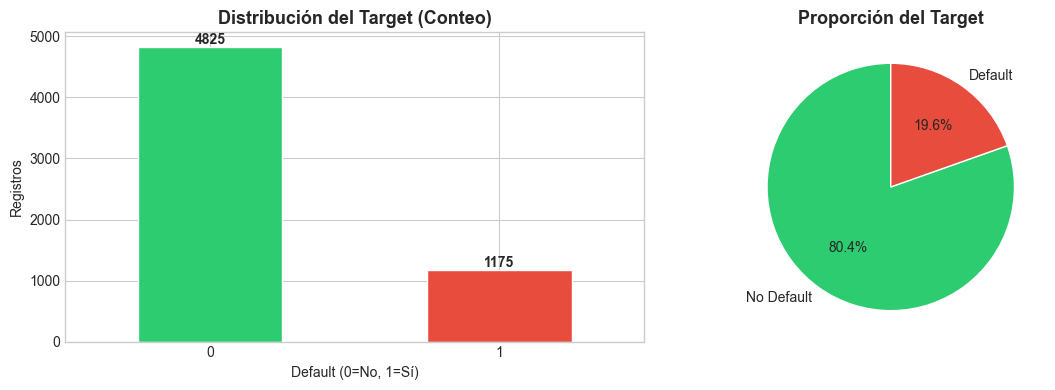


 Desbalance detectado: 19.6% de defaults


In [115]:
# ============================================================
# DISTRIBUCIÓN DEL TARGET
# ============================================================
target_counts = df['default'].value_counts()
target_pct    = df['default'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'],
                   edgecolor='white', rot=0)
axes[0].set_title('Distribución del Target (Conteo)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Default (0=No, 1=Sí)')
axes[0].set_ylabel('Registros')
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

target_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                colors=['#2ecc71','#e74c3c'], startangle=90,
                labels=['No Default','Default'])
axes[1].set_title('Proporción del Target', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"\n Desbalance detectado: {target_pct[1]:.1f}% de defaults")


## 3. Pre-procesamiento de Datos

### 3.1 Análisis de Valores Faltantes

=== VARIABLES CON VALORES FALTANTES ===
                       Faltantes  Porcentaje (%)
employment_years             326          5.4300
savings_balance              324          5.4000
credit_utilization           310          5.1700
credit_history_length        284          4.7300
income                       279          4.6500


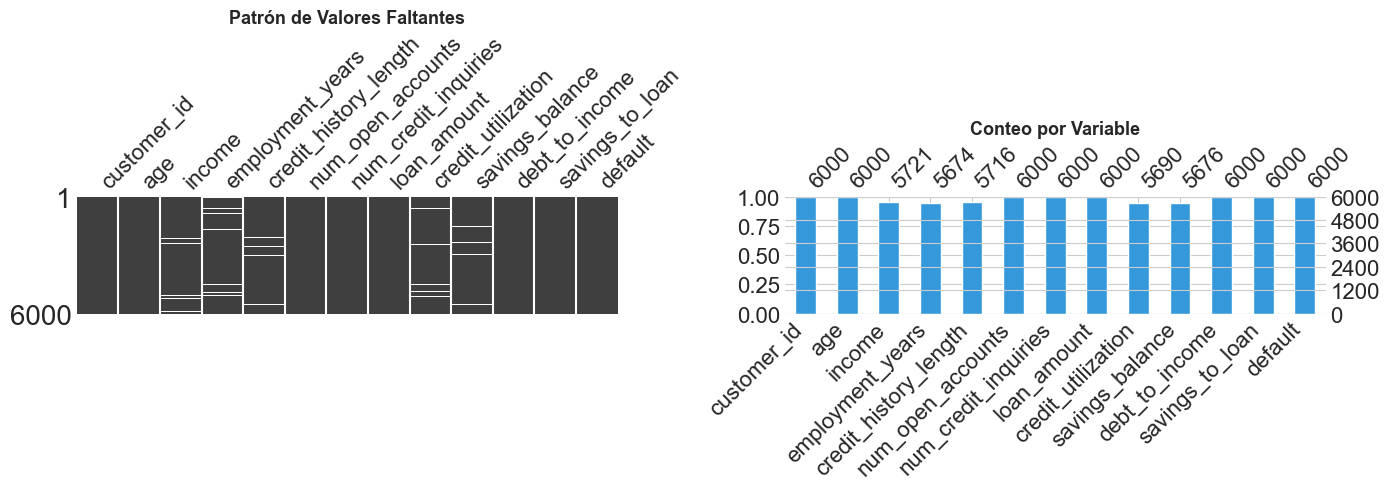

In [116]:
# ============================================================
# VALORES FALTANTES — DIAGNÓSTICO
# ============================================================
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje (%)': missing_pct})
missing_df = missing_df[missing_df['Faltantes'] > 0]

print("=== VARIABLES CON VALORES FALTANTES ===")
print(missing_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
msno.matrix(df, ax=axes[0], sparkline=False)
axes[0].set_title('Patrón de Valores Faltantes', fontsize=13, fontweight='bold')
msno.bar(df, ax=axes[1], color='#3498db')
axes[1].set_title('Conteo por Variable', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.2 Evaluación de Multicolinealidad



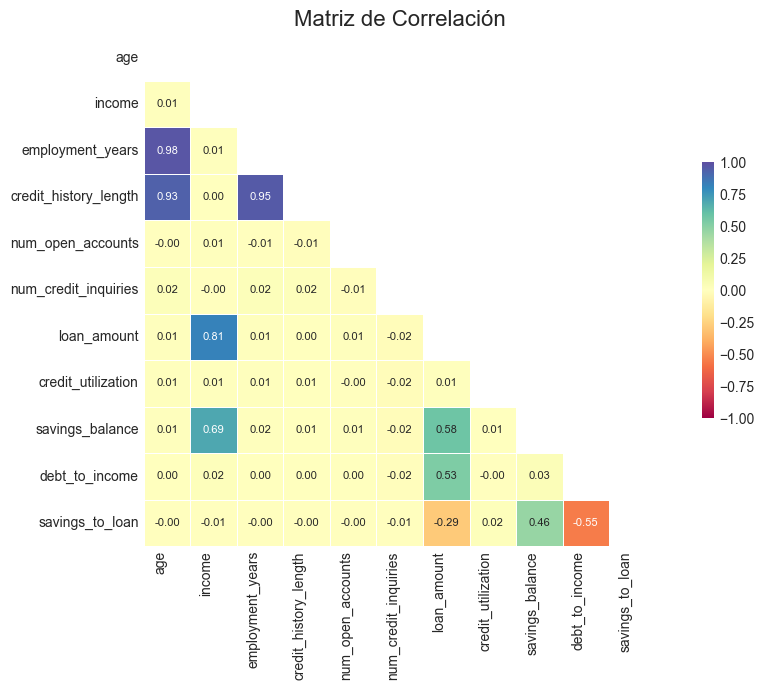

In [117]:
# TRAIN

# Variables numéricas (excluye ID y target)
v_num = [c for c in df.select_dtypes(include=[np.number]).columns 
         if c not in ['customer_id', 'default']]

corr = df[v_num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 7))
sns.set_style("white")

sns.heatmap(corr, mask=mask, cmap="Spectral",
            vmin=-1, vmax=1, square=True,
            annot=True, fmt=".2f", annot_kws={"size": 8}, linewidths=0.5,
            cbar_kws={"shrink": 0.5, "aspect": 20}, linecolor='white')

plt.xticks(fontsize=10, rotation=90, ha="right")
plt.yticks(fontsize=10, rotation=0)
plt.title("Matriz de Correlación", fontsize=16)
plt.tight_layout()
plt.show()

In [118]:
# Dado que observamos una alta correlación entre mis variables, lo mejor sería desechar las redundantes para evitar problemas de multicolinealidad 
cols_drop = ['age', 'employment_years']
df1 = df.drop(columns=cols_drop)
df1.columns
# mantenemos credit_history_length, por ser una variable importante en credit scoring

Index(['customer_id', 'income', 'credit_history_length', 'num_open_accounts',
       'num_credit_inquiries', 'loan_amount', 'credit_utilization',
       'savings_balance', 'debt_to_income', 'savings_to_loan', 'default'],
      dtype='object')

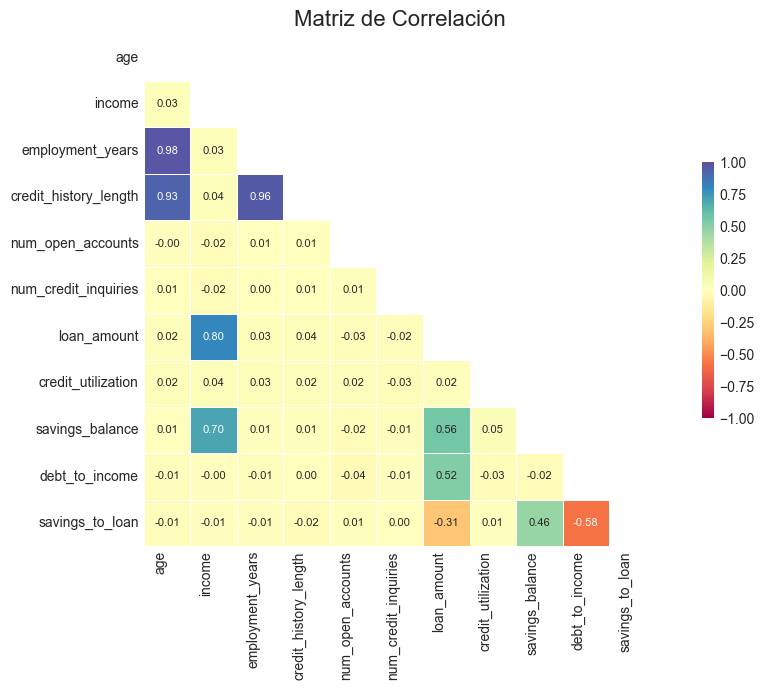

In [119]:
## TEST 

# Variables numéricas (excluye ID y target)
v_num = [c for c in test.select_dtypes(include=[np.number]).columns 
         if c not in ['customer_id', 'default']]

corr = test[v_num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 7))
sns.set_style("white")

sns.heatmap(corr, mask=mask, cmap="Spectral",
            vmin=-1, vmax=1, square=True,
            annot=True, fmt=".2f", annot_kws={"size": 8}, linewidths=0.5,
            cbar_kws={"shrink": 0.5, "aspect": 20}, linecolor='white')

plt.xticks(fontsize=10, rotation=90, ha="right")
plt.yticks(fontsize=10, rotation=0)
plt.title("Matriz de Correlación", fontsize=16)
plt.tight_layout()
plt.show()

In [120]:
# Dado que observamos una alta correlación entre mis variables, lo mejor sería desechar las redundantes para evitar problemas de multicolinealidad 
cols_drop = ['age', 'employment_years']
test1 = test.drop(columns=cols_drop)
test1.columns
# mantenemos credit_history_length, por ser una variable importante en credit scoring

Index(['customer_id', 'income', 'credit_history_length', 'num_open_accounts',
       'num_credit_inquiries', 'loan_amount', 'credit_utilization',
       'savings_balance', 'debt_to_income', 'savings_to_loan'],
      dtype='object')

### 3.3 Imputación de Valores Faltantes

Usaremos la distancia de grower, para realizar las imputaciones; dado que la sospecha es de un MAR, la mediana funciona también; pero primero intentaremos con el método de KNN


In [121]:
# Creando la función de Knn usando la distancia de Gower para imputar 

def knn_gower_imputer(df, cols_to_impute, k=5):
    """
    Imputa valores nulos usando KNN con distancia de Gower.
    Usa todo el dataframe para calcular similitud entre clientes.
    """
    df_work = df.copy()
    
    for col in cols_to_impute:
        missing_idx = df_work[df_work[col].isnull()].index
        present_idx = df_work[df_work[col].notna()].index
        
        if len(missing_idx) == 0:
            print(f"  {col}: sin nulos, se omite.")
            continue
        
        print(f"  Imputando '{col}' → {len(missing_idx)} nulos...")
        
        # Usa todo el df excepto la columna objetivo para calcular distancias
        features = df_work.drop(columns=[col])
        
        dist = gower.gower_matrix(
            features.loc[missing_idx],
            features.loc[present_idx]
        )
        
        for i, idx in enumerate(missing_idx):
            k_neighbors = present_idx[np.argsort(dist[i])[:k]]
            df_work.loc[idx, col] = df_work.loc[k_neighbors, col].median()
        
        print(f"  ✓ '{col}' imputado.")
    
    return df_work



In [122]:
# ============================================================
# IMPUTACIÓN — MEDIANA POR GRUPO DE DEFAULT
# usamos distancia de gower con el algoritmo KNN
# diferencial entre clientes en default vs no default
# ============================================================
vars_con_missing = ['savings_balance',
                    'credit_utilization', 'credit_history_length', 'income']

df_clean =  knn_gower_imputer(df1, vars_con_missing, k=5)

missing_post = df_clean.isnull().sum().sum()
print(f"Valores faltantes restantes en train: {missing_post}")
print(f"   Shape final: {df_clean.shape}")


  Imputando 'savings_balance' → 324 nulos...
  ✓ 'savings_balance' imputado.
  Imputando 'credit_utilization' → 310 nulos...
  ✓ 'credit_utilization' imputado.
  Imputando 'credit_history_length' → 284 nulos...
  ✓ 'credit_history_length' imputado.
  Imputando 'income' → 279 nulos...
  ✓ 'income' imputado.
Valores faltantes restantes en train: 0
   Shape final: (6000, 11)


In [123]:
# ============================================================
# IMPUTACIÓN EN TEST (misma estrategia, mediana global)
# ============================================================
test_clean = knn_gower_imputer(test1, vars_con_missing, k=5)
missing_test_post = test_clean.isnull().sum().sum()
print(f"Valores faltantes restantes en test: {missing_test_post}")


  Imputando 'savings_balance' → 111 nulos...
  ✓ 'savings_balance' imputado.
  Imputando 'credit_utilization' → 92 nulos...
  ✓ 'credit_utilization' imputado.
  Imputando 'credit_history_length' → 105 nulos...
  ✓ 'credit_history_length' imputado.
  Imputando 'income' → 105 nulos...
  ✓ 'income' imputado.
Valores faltantes restantes en test: 0


### 3.4 Limpieza Adicional

In [124]:
# ============================================================
# ELIMINAR customer_id del train (no es variable predictora)
# ============================================================
if 'customer_id' in df_clean.columns:
    df_clean1 = df_clean.drop(columns=['customer_id'])
else:
    df_clean1 = df_clean.copy()

test_clean1 = test_clean.copy()

print(f"Train para modelado: {df_clean1.shape}")
print(f"Test  para modelado: {test_clean1.shape}")
print(f"\nColumnas train: {df_clean1.columns.tolist()}")


Train para modelado: (6000, 10)
Test  para modelado: (2000, 10)

Columnas train: ['income', 'credit_history_length', 'num_open_accounts', 'num_credit_inquiries', 'loan_amount', 'credit_utilization', 'savings_balance', 'debt_to_income', 'savings_to_loan', 'default']


### 3.5 OUTLIERS

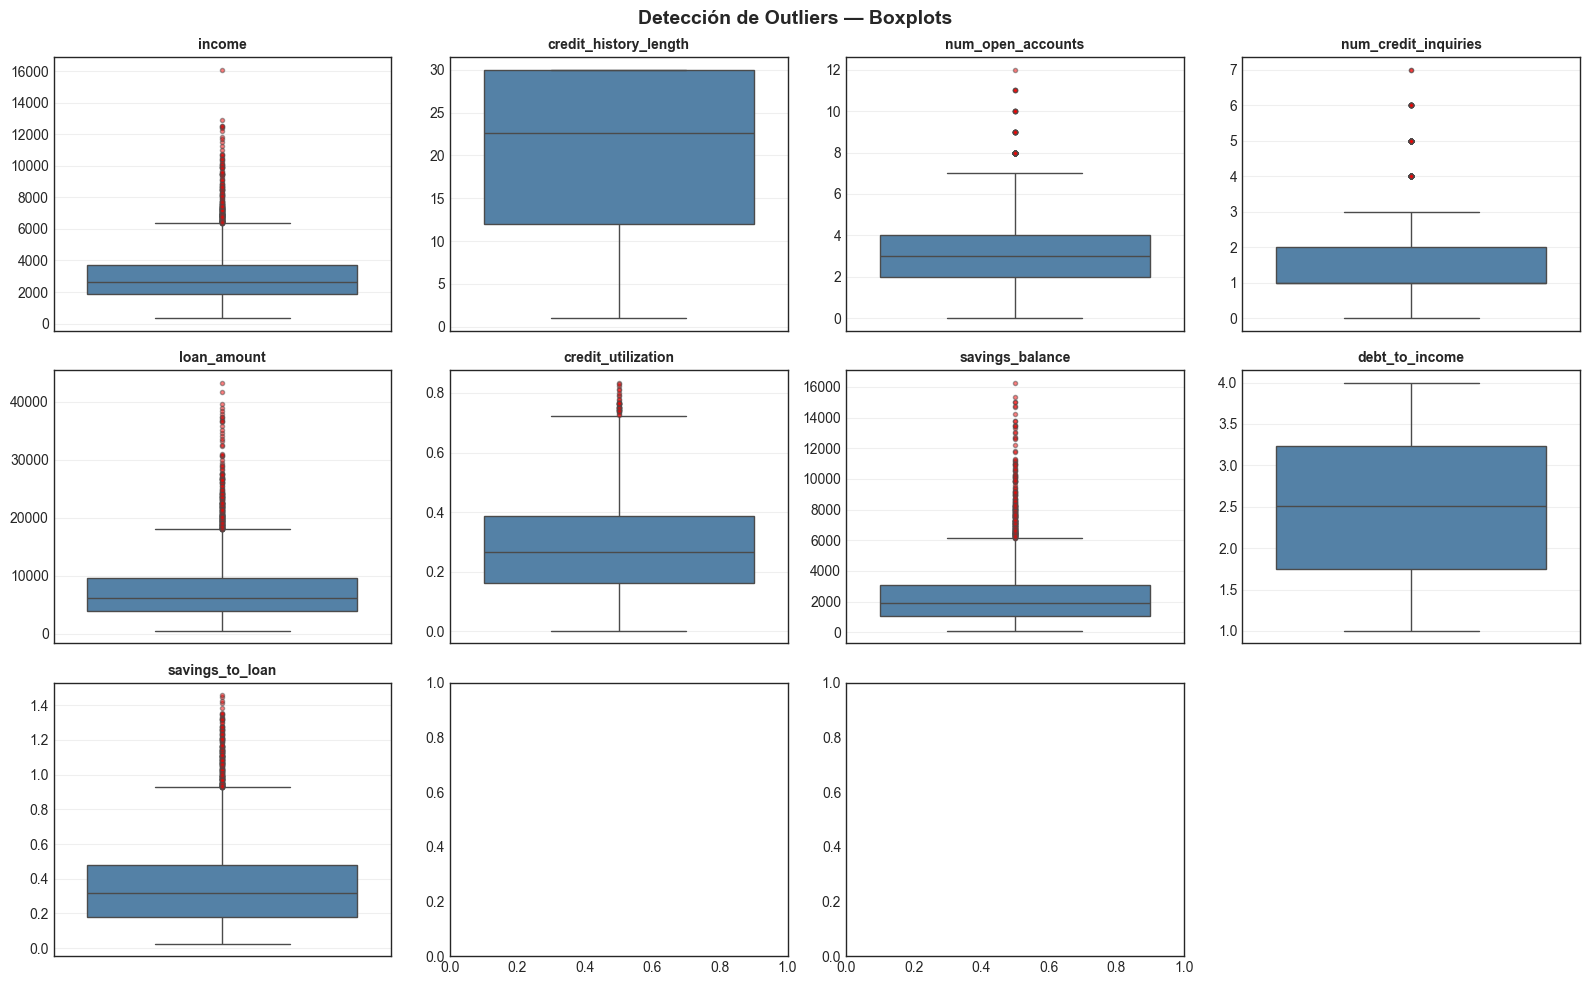

In [125]:

v_num = [c for c in df_clean.select_dtypes(include=[np.number]).columns 
         if c not in ['customer_id', 'default']]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

sns.set_style("white")


for i, col in enumerate(v_num):
    sns.boxplot(y=df_clean[col], ax=axes[i], color='steelblue',
                flierprops=dict(marker='o', markerfacecolor='red', 
                                markersize=3, alpha=0.5))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('')
    axes[i].grid(axis='y', alpha=0.3)

# Ocultar subplot sobrante (3x4=12 celdas, solo 11 variables)
axes[-1].set_visible(False)

plt.suptitle("Detección de Outliers — Boxplots", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Vemos que hay muchos outliers, pero podemos discretizar y así tratarlos de forma más 'amigable' y evitamos que se pierda información. Luego en la parte inferior cuando usamos el WOE aplicamos los mismos BINS para el testing, de cierta forma hacemos esa discretización (colocar datos continuos a intervalos)

## 4. Feature Engineering — WOE Binning

### ¿Qué es WOE (Weight of Evidence)?

El **WOE** es una transformación que:
- Agrupa valores en *bins* de riesgo similar mediante discretización óptima
- Captura relaciones **no lineales** entre variables y el target
- Calcula el **Information Value (IV)** para medir el poder predictivo de cada variable
- Mejora la interpretabilidad del modelo (estándar en Credit Scoring)

**Criterio de selección por IV:**

| IV | Poder Predictivo |
|:---:|:---|
| < 0.02 | Sin poder predictivo |
| 0.02 – 0.1 | Débil |
| 0.1 – 0.3 | Medio |
| 0.3 – 0.5 | Fuerte |
| > 0.5 | Sospechoso (posible data leakage) |


In [ ]:
# WOE BINNING — Entrenado SOLO con datos de train

bins = sc.woebin(df_clean1, y="default")
bins


Calculando WOE bins...
[INFO] creating woe binning ...
WOE calculado para 9 variables


{'num_open_accounts':             variable         bin  count  count_distr  good  bad  badprob  \
 0  num_open_accounts  [-inf,2.0)   1131       0.1885   940  191   0.1689   
 1  num_open_accounts   [2.0,3.0)   1359       0.2265  1107  252   0.1854   
 2  num_open_accounts   [3.0,5.0)   2401       0.4002  1928  473   0.1970   
 3  num_open_accounts   [5.0,inf)   1109       0.1848   850  259   0.2335   
 
       woe  bin_iv  total_iv breaks  is_special_values  
 0 -0.1811  0.0058    0.0168    2.0              False  
 1 -0.0674  0.0010    0.0168    3.0              False  
 2  0.0074  0.0000    0.0168    5.0              False  
 3  0.2241  0.0099    0.0168    inf              False  ,
 'credit_utilization':              variable          bin  count  count_distr  good  bad  badprob  \
 0  credit_utilization  [-inf,0.12)    902       0.1503   780  122   0.1353   
 1  credit_utilization   [0.12,0.3)   2570       0.4283  2143  427   0.1661   
 2  credit_utilization    [0.3,0.5)   1914     

**OJO**

Como algo extra para saber sobre los algoritmos dentro de las funciones importantes; como es el ***sc.woebin()*** 

EXPLICACIÓN

Datos ordenados:

income:  500   800  1200  1500  2000  2800  3500  6500  16000

default:  1     1    0     1     0     0     0     0      0

Prueba corte en 1000:

  Grupo ≤ 1000:  [500, 800]      → 0 buenos, 2 malos  → muy malo

  Grupo > 1000:  [1200...16000]  → 7 buenos, 1 malo   → muy bueno

  Chi² = 8.2

Prueba corte en 1500:

  Grupo ≤ 1500:  [500,800,1200,1500] → 1 bueno, 3 malos → malo

  Grupo > 1500:  [2000...16000]      → 6 buenos, 0 malos → muy bueno

  Chi² = 11.7  ← mejor

Prueba corte en 2000:

  Chi² = 9.1  ← peor que 1500

Dentro de la función sc.woebin usan árboles para establecer los puntos de cortes para establecer diferencias significativas entre buenos y malos; y justamente para eso se usa el estadístico chi-cuadrado que se usa como medida de qué tan diferente es la distribución de buenos y malos entre dos grupos.

El algoritmo pregunta: ¿Si corto aquí, los grupos resultantes tienen distribuciones de default significativamente distintas?

El estadístico es el siguiente:


$X^2 = \frac{\sum(O_{i}-E^2_{i})}{E_{i}}$


                variable  total_iv
0         debt_to_income    0.4753
1  credit_history_length    0.4486
2        savings_to_loan    0.4108
3        savings_balance    0.1479
4                 income    0.1307
5     credit_utilization    0.0947
6            loan_amount    0.0441
7   num_credit_inquiries    0.0363
8      num_open_accounts    0.0168


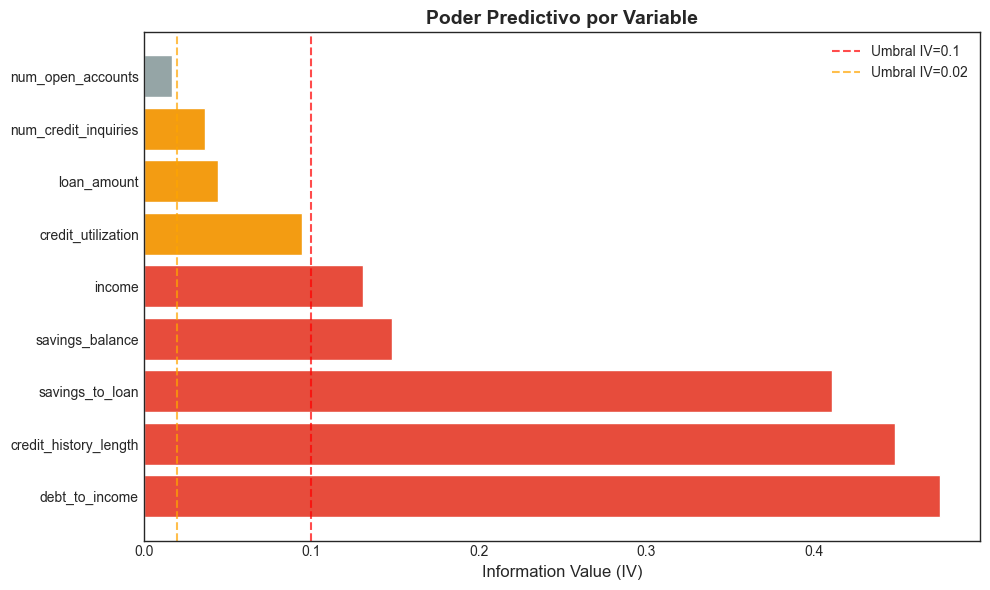

In [127]:
## PODER PREDICTIVO CON EL IV

iv_list = []

for var, df_bin in bins.items():
    # scorecardpy usa: good_distr, bad_distr, woe, bin_iv
    # bin_iv ya es (good_distr - bad_distr) * woe por bin
    iv_total = df_bin['bin_iv'].sum()
    iv_list.append((var, round(iv_total, 4)))

iv_df = pd.DataFrame(iv_list, columns=["variable", "total_iv"])
iv_df = iv_df.sort_values(by='total_iv', ascending=False).reset_index(drop=True)
print(iv_df)

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if iv > 0.1 else '#f39c12' if iv > 0.02 else '#95a5a6'
          for iv in iv_df['total_iv']]
ax.barh(iv_df['variable'], iv_df['total_iv'], color=colors, edgecolor='white')
ax.axvline(x=0.1, color='red', linestyle='--', alpha=0.7, label='Umbral IV=0.1')
ax.axvline(x=0.02, color='orange', linestyle='--', alpha=0.7, label='Umbral IV=0.02')
ax.set_xlabel('Information Value (IV)', fontsize=12)
ax.set_title('Poder Predictivo por Variable', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


In [128]:
# ============================================================
# SELECCIÓN DE VARIABLES CON IV > 0.02
# ============================================================
good_vars = iv_df.loc[iv_df['total_iv'] > 0.1, 'variable'].tolist()

print("=== VARIABLES SELECCIONADAS PARA MODELADO ===")
iv_selected = iv_df[iv_df['variable'].isin(good_vars)]
print(iv_selected.to_string(index=False))
print(f"\n Total variables seleccionadas: {len(good_vars)}")
print(f"   IV Promedio: {iv_selected['total_iv'].mean():.4f}")
print(f"   Variables: {good_vars}")


=== VARIABLES SELECCIONADAS PARA MODELADO ===
             variable  total_iv
       debt_to_income    0.4753
credit_history_length    0.4486
      savings_to_loan    0.4108
      savings_balance    0.1479
               income    0.1307

 Total variables seleccionadas: 5
   IV Promedio: 0.3227
   Variables: ['debt_to_income', 'credit_history_length', 'savings_to_loan', 'savings_balance', 'income']


In [129]:
# ============================================================
# APLICAR TRANSFORMACIÓN WOE A TRAIN Y TEST
# ============================================================
train_woe = sc.woebin_ply(df_clean1, bins)
test_woe  = sc.woebin_ply(test_clean1, bins)

# Variables WOE para modelado
woe_cols = [col + "_woe" for col in good_vars]

X = train_woe[woe_cols]
y = train_woe['default']

# Asegurar mismo orden en test
X_test_woe = test_woe[woe_cols]

print(f"Train WOE shape: {X.shape}")
print(f"Test  WOE shape: {X_test_woe.shape}")
print(f"\nPrimeras filas de train WOE:")
X.head()


[INFO] converting into woe values ...
[INFO] converting into woe values ...
Train WOE shape: (6000, 5)
Test  WOE shape: (2000, 5)

Primeras filas de train WOE:


,debt_to_income_woe,credit_history_length_woe,savings_to_loan_woe,savings_balance_woe,income_woe
0,-1.3519,0.6288,0.4925,0.5411,0.2824
1,0.7409,-0.8525,0.1741,-1.1375,-0.5362
2,-1.3519,-0.8525,-0.7690,-0.3552,-0.1921
3,-0.4360,0.6288,0.1741,-0.3552,-0.1921
4,0.2274,-0.8525,0.1741,-0.0845,0.2824


## 5. Preparación de Train / Validación

Separo el TRAIN en 80% y 20% para evaluar las métricas con data balanceada y así aprenda el modelo de la clase mayoritaria y minoritaria; y el otro 20% es lo real. Luego comparamos las medidas de las dos particiones para ver si se detecta overfitting.

In [130]:
# ============================================================
# SPLIT TRAIN / VALIDACIÓN (80/20 estratificado)
# ============================================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}  |  Default rate: {y_train.mean():.3f}")
print(f"Val:   {X_val.shape}    |  Default rate: {y_val.mean():.3f}")


Train: (4800, 5)  |  Default rate: 0.196
Val:   (1200, 5)    |  Default rate: 0.196


In [131]:
# ============================================================
# BALANCEO CON SMOTE
# Genera muestras sintéticas de la clase minoritaria (default=1)
# para equilibrar  eldataset de entrenamiento y evitar que el modelo aprenda de la clase mayoritaria y causar overffiting
# ============================================================
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Antes de SMOTE → 0: {sum(y_train==0):,}  |  1: {sum(y_train==1):,}")
print(f"Después de SMOTE → 0: {sum(y_train_bal==0):,}  |  1: {sum(y_train_bal==1):,}")
print(f"\nShape train balanceado: {X_train_bal.shape}")


Antes de SMOTE → 0: 3,860  |  1: 940
Después de SMOTE → 0: 3,860  |  1: 3,860

Shape train balanceado: (7720, 5)


## 6. Modelado — Regresión Logística

### Modelo Elegido: Regresión Logística

La **Regresión Logística** es el estándar de la industria para Credit Scoring porque:
- Es **interpretable** (coeficientes = pesos de riesgo)
- Compatible directamente con **WOE** (relación lineal en el espacio transformado)
- Produce **probabilidades calibradas**
- Es el modelo exigido por la competencia


In [132]:
# ============================================================
# BÚSQUEDA DE HIPERPARÁMETROS — GridSearchCV
# GridSearch prueba sistemáticamente todas las combinaciones
# de parámetros y selecciona la que maximiza AUC-ROC en CV=5
# ============================================================
params = {
    'C':       [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid = params,
    cv         = 5,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 0
)

grid.fit(X_train_bal, y_train_bal)

print("=" * 55)
print("  RESULTADOS GRIDSEARCHCV")
print("=" * 55)
print(f"  Mejores parámetros:  {grid.best_params_}")
print(f"  Mejor AUC (CV=5):    {grid.best_score_:.4f}")
print("=" * 55)

best_model = grid.best_estimator_


  RESULTADOS GRIDSEARCHCV
  Mejores parámetros:  {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
  Mejor AUC (CV=5):    0.7919


## 7. Evaluación del Modelo

In [ ]:
y_pred_train      = best_model.predict(X_train_bal)
y_prob_train      = best_model.predict_proba(X_train_bal)[:, 1]

y_pred_val        = best_model.predict(X_val)
y_prob_val        = best_model.predict_proba(X_val)[:, 1]


In [ ]:
# MÉTRICAS COMPARATIVAS TRAIN vs VALIDACIÓN
def print_metrics(y_true, y_pred, y_prob, nombre):
    print(f"\n{'='*55}")
    print(f"  {nombre}")
    print(f"{'='*55}")
    print(f"  Accuracy:   {accuracy_score(y_true, y_pred):.4f}")
    print(f"  AUC-ROC:    {roc_auc_score(y_true, y_prob):.4f}")
    print(f"  F1-Score:   {f1_score(y_true, y_pred):.4f}")
    print(f"  Precision:  {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall:     {recall_score(y_true, y_pred):.4f}")
    print()
    print(classification_report(y_true, y_pred, digits=4,
                                 target_names=['No Default','Default']))
    
print_metrics(y_train_bal, y_pred_train, y_prob_train, "TRAIN BALANCEADO")
#              ↑ y_true       ↑ y_pred      ↑ y_prob
#           valores reales  predice modelo  prob. modelo

print_metrics(y_val,y_pred_val,y_prob_val," TRAIN VALIDACIÓN (real sin balanceo)")



  TRAIN BALANCEADO
  Accuracy:   0.7179
  AUC-ROC:    0.7919
  F1-Score:   0.7280
  Precision:  0.7028
  Recall:     0.7549

              precision    recall  f1-score   support

  No Default     0.7353    0.6808    0.7070      3860
     Default     0.7028    0.7549    0.7280      3860

    accuracy                         0.7179      7720
   macro avg     0.7191    0.7179    0.7175      7720
weighted avg     0.7191    0.7179    0.7175      7720


   TRAIN VALIDACIÓN (real sin balanceo)
  Accuracy:   0.6942
  AUC-ROC:    0.7864
  F1-Score:   0.4924
  Precision:  0.3648
  Recall:     0.7574

              precision    recall  f1-score   support

  No Default     0.9199    0.6788    0.7812       965
     Default     0.3648    0.7574    0.4924       235

    accuracy                         0.6942      1200
   macro avg     0.6423    0.7181    0.6368      1200
weighted avg     0.8112    0.6942    0.7246      1200



Si Precision sube → los Falsos Positivos bajan

Si Precision baja → los Falsos Positivos suben

Si Recall sube --> Los falsos negativos bajan

Si Recall baja --> los falsos positivos suben

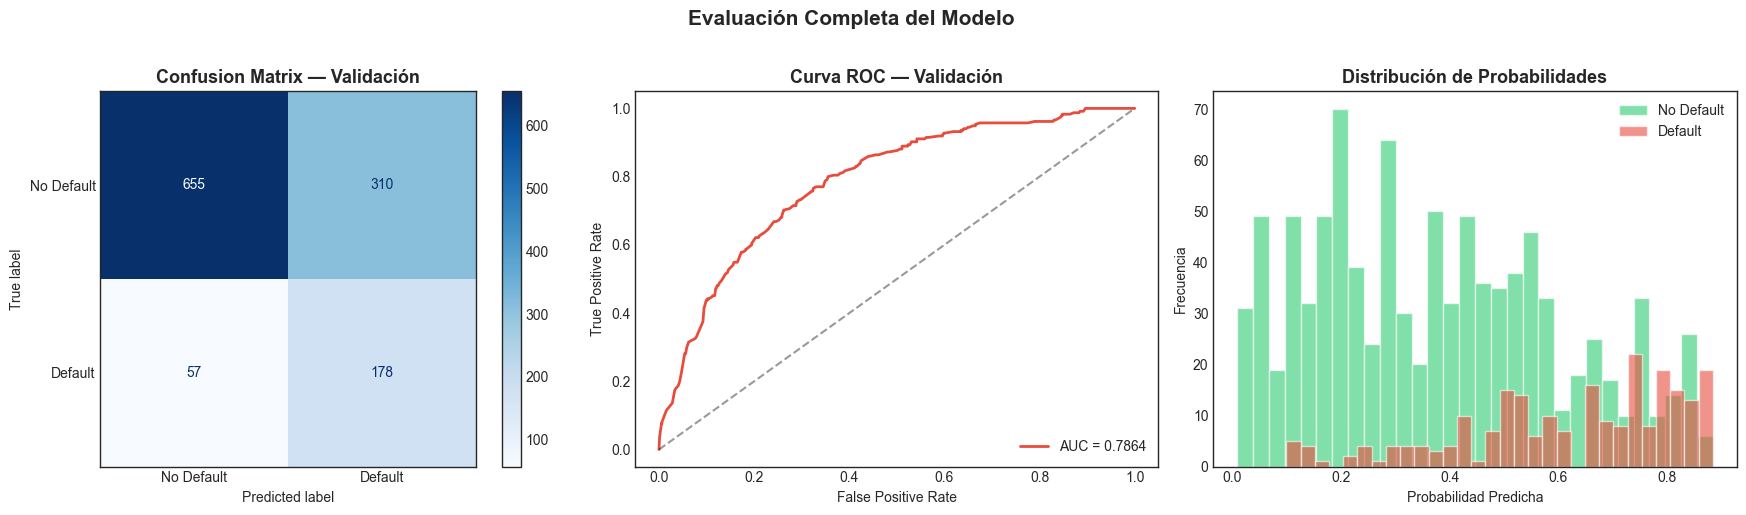

In [135]:
# ============================================================
# VISUALIZACIONES DE EVALUACIÓN
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# — Confusion Matrix —
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_val,
    display_labels=['No Default','Default'],
    ax=axes[0], cmap='Blues'
)
axes[0].set_title('Confusion Matrix — Validación', fontsize=13, fontweight='bold')

# — Curva ROC —
fpr, tpr, _ = roc_curve(y_val, y_prob_val)
auc_score   = roc_auc_score(y_val, y_prob_val)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'AUC = {auc_score:.4f}')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC — Validación', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

# — Distribución de Probabilidades —
axes[2].hist(y_prob_val[y_val==0], bins=30, alpha=0.6,
             color='#2ecc71', label='No Default')
axes[2].hist(y_prob_val[y_val==1], bins=30, alpha=0.6,
             color='#e74c3c', label='Default')
axes[2].set_xlabel('Probabilidad Predicha')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Distribución de Probabilidades', fontsize=13, fontweight='bold')
axes[2].legend()

plt.suptitle('Evaluación Completa del Modelo', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


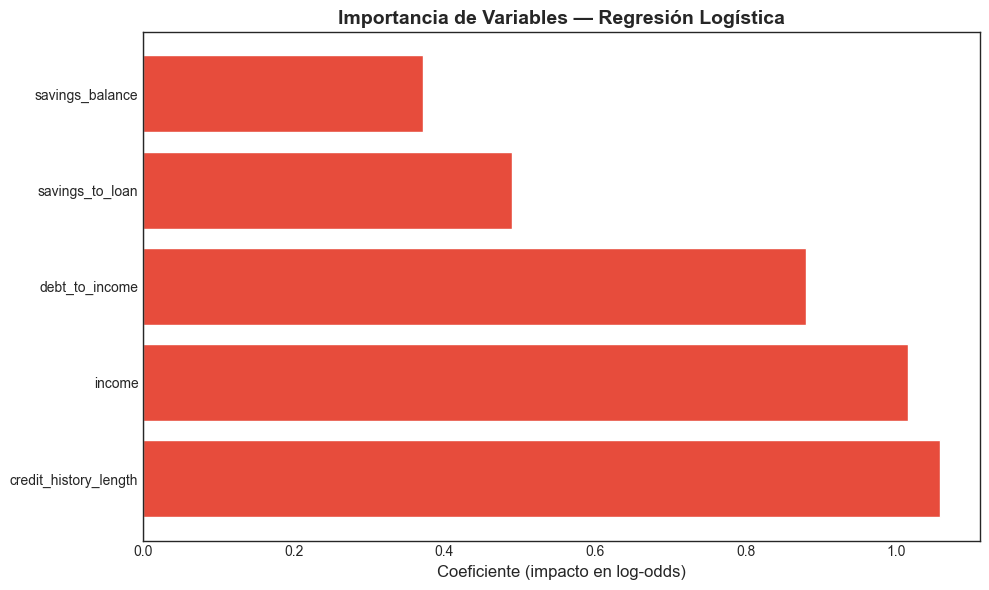


 Positivo = aumenta riesgo de default
 Negativo = reduce riesgo de default


In [142]:
# ============================================================
# IMPORTANCIA DE VARIABLES (Coeficientes WOE)
# ============================================================
coefs = pd.DataFrame({
    'Variable':    woe_cols,
    'Coeficiente': best_model.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coefs['Coeficiente']]
ax.barh(coefs['Variable'].str.replace('_woe',''), coefs['Coeficiente'],
        color=colors, edgecolor='white')
ax.axvline(x=0, color='black', lw=0.8)
ax.set_xlabel('Coeficiente (impacto en log-odds)', fontsize=12)
ax.set_title('Importancia de Variables — Regresión Logística',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Positivo = aumenta riesgo de default")
print(" Negativo = reduce riesgo de default")


## 8. Predicciones y Generación de Submission

In [141]:
# ============================================================
# PREDICCIÓN SOBRE TEST
# Aseguramos el mismo orden de columnas que el train
# ============================================================
X_test = X_test_woe[X_train_bal.columns.tolist()]

y_prob_test = best_model.predict_proba(X_test)[:, 1]

print(f"   Predicciones generadas: {len(y_prob_test)}")
print(f"   Rango: [{y_prob_test.min():.4f}, {y_prob_test.max():.4f}]")
print(f"   Media: {y_prob_test.mean():.4f}")


   Predicciones generadas: 2000
   Rango: [0.0089, 0.8850]
   Media: 0.4203


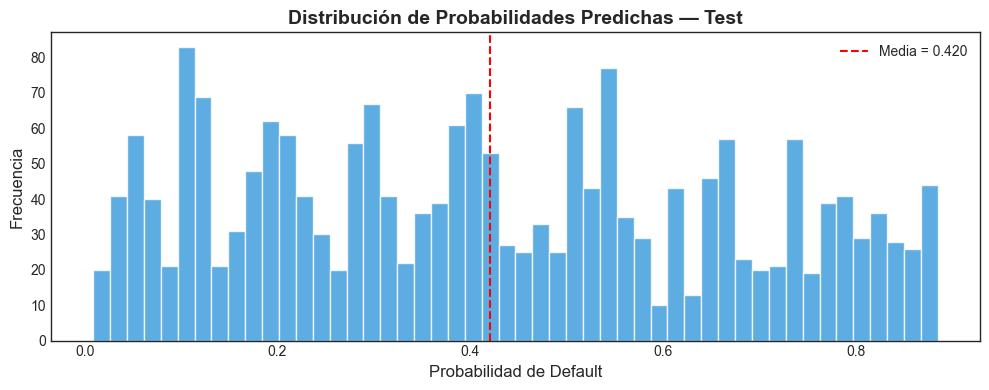

In [138]:
# ============================================================
# DISTRIBUCIÓN DE PROBABILIDADES EN TEST
# ============================================================
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_prob_test, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
ax.set_xlabel('Probabilidad de Default', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('Distribución de Probabilidades Predichas — Test', fontsize=14, fontweight='bold')
ax.axvline(y_prob_test.mean(), color='red', linestyle='--',
           label=f'Media = {y_prob_test.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# GENERAR SUBMISSION

submission = pd.DataFrame({
    "customer_id":        test["customer_id"],
    "default_probability": y_prob_test
})

print(submission.head(10).to_string(index=False))
print(f"\nShape: {submission.shape}")
print(f"¿NaN?: {submission.isnull().sum().sum()}")


=== SUBMISSION PREVIEW ===
 customer_id  default_probability
           2               0.3945
           3               0.1925
           4               0.8850
           5               0.2028
           9               0.7264
          10               0.5388
          16               0.7212
          34               0.4678
          36               0.2323
          38               0.1662

Shape: (2000, 2)
¿NaN?: 0


In [ ]:
# ============================================================
# GUARDAR SUBMISSION
# ============================================================
submission.to_csv('submission_final.csv', index=False)
print("submission_final.csv guardado en la carpeta del notebook")


✅ submission_final.csv guardado en la carpeta del notebook
